# Customer Segmentation Pipeline
## Telecom Customer Clustering using KMeans

**Author:** Martin James Ng'ang'a | github.com/M20Jay  

**Dataset:** IBM Telco Customer Churn Dataset  

**Goal:** Identify customer segments to drive targeted retention and offers 
 
**Stack:** KMeans · PCA · StandardScaler · MLflow · Streamlit · PostgreSQL · AWS

In [1]:
# ── Section 1: Import Libraries ──────────────────────────────────
# pandas   → data manipulation — loading and exploring the dataset
# numpy    → numerical operations
# matplotlib → plotting charts
# seaborn  → prettier statistical charts
# sklearn  → machine learning tools
#            StandardScaler — scaling features
#            PCA — dimensionality reduction
#            KMeans — clustering algorithm
#            silhouette_score — measuring cluster quality
# mlflow   → experiment tracking

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import mlflow

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## Section 2: Load and Explore the Data

In [2]:
# ── Section 2: Load and Explore Data ─────────────────────────────
# We reuse the same Telco dataset from Week 1
# Same data — different question
# Week 1: "Who will churn?" (supervised — had labels)
# Week 3: "Who are our customer groups?" (unsupervised — no labels)
# Load the dataset
df = pd.read_csv('/Users/martinjames/Documents/GitHub/churn-prediction-pipeline/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✅ Dataset loaded")
print(f"    Rows: {df.shape[0]}:,")
print(f"    Columns: {df.shape[1]}")
print(f"\ncolumn names:")
print(df.columns.tolist())
print(f"\nFirst 3 rows:")
df.head(3)

✅ Dataset loaded
    Rows: 7043:,
    Columns: 21

column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Section 3: Exploratory Data Analysis (EDA)

In [3]:
# ── Section 3: EDA ───────────────────────────────────────────────
# Before clustering we must understand the data
# EDA answers:
# → What does the data look like?
# → Are there missing values?
# → What are the distributions?
# → Which features are useful for segmentation?

# Step 1 — Basic info
print("=== Dataset Info ===")
print(f" Shape: {df.shape}")
print(f"\nData Types")
print(df.dtypes)

# Step 2 — Fix TotalCharges and check missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("Missing values after fixing TotalCharges:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"TotalCharges dtype now: {df['TotalCharges'].dtype}")


=== Dataset Info ===
 Shape: (7043, 21)

Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Missing values after fixing TotalCharges:
TotalCharges    11
dtype: int64
TotalCharges dtype now: float64


## Section 4: Data Cleaning and Feature Engineering

In [4]:
# ── Section 4: Data Cleaning and Feature Engineering ─────────────
# Drop rows with missing TotalCharges
df =df.dropna(subset = "TotalCharges")

# Calculate ARPU — Average Revenue Per User
# Key telecom business metric
# How much does this customer pay per month on average?
df['ARPU'] = df['TotalCharges']/df['tenure'].replace(0,1)

print(f"Rows after dropping missing: {df.shape[0]:,}")
print(f"\nARPU sample statistics....")
print(df['ARPU'].describe().round(2))


Rows after dropping missing: 7,032

ARPU sample statistics....
count    7032.00
mean       64.80
std        30.19
min        13.78
25%        36.18
50%        70.37
75%        90.18
max       121.40
Name: ARPU, dtype: float64


## Section 5: Feature Selection for Clustering

In [5]:
# ── Section 5: Feature Selection ─────────────────────────────────
# KMeans needs NUMERICAL features only
# We select behaviour features that describe
# how a customer uses and pays for the service

# Remove columns not useful for clustering:
# customerID → identifier only
# Churn      → this is a label — we ignore it
#              unsupervised learning has no labels
# gender, Partner etc → demographics not behaviour

features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ARPU',
    'SeniorCitizen'
]

df_cluster = df[features].copy()
print(f"✅ Features selected for clustering:")
for f in features:
    print(f"    {f}")
print(f"\nShape: {df_cluster.shape}")
print("\nSample:")
print(df_cluster.head(3).round(2))

✅ Features selected for clustering:
    tenure
    MonthlyCharges
    TotalCharges
    ARPU
    SeniorCitizen

Shape: (7032, 5)

Sample:
   tenure  MonthlyCharges  TotalCharges   ARPU  SeniorCitizen
0       1           29.85         29.85  29.85              0
1      34           56.95       1889.50  55.57              0
2       2           53.85        108.15  54.08              0


## Section 6: StandardScaler — Scale the Features

In [6]:
# ── Section 6: StandardScaler ────────────────────────────────────
# KMeans uses distance to group customers
# Features with larger numbers dominate the distance
# StandardScaler fixes this by putting all features
# on the same scale — mean=0, std=1

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
print("✅ Features scaled successfully")
print(f"\nBefore scaling — MonthlyCharges range:")
print(f"    Min: {df_cluster['MonthlyCharges'].min():.2f}")
print(f"    Max: {df_cluster['MonthlyCharges'].max():.2f}")

print(f"\nAftr scaling - MonthlyCharges range:")
print(f"    Min: {df_scaled[:,1].min():.2f}")
print(f"    Max: {df_scaled[:,1].max():.2f}")


✅ Features scaled successfully

Before scaling — MonthlyCharges range:
    Min: 18.25
    Max: 118.75

Aftr scaling - MonthlyCharges range:
    Min: -1.55
    Max: 1.79


## Section 7: PCA — Reduce to 2 Dimensions for Visualisation

In [7]:
# ── Section 7: PCA ───────────────────────────────────────────────
# PCA = Principal Component Analysis
# Reduces 5 features → 2 dimensions
# So we can VISUALISE the clusters on a 2D chart
# PCA does NOT improve the model
# It only helps us SEE the clusters

pca = PCA(n_components = 2)
df_pca = pca.fit_transform(df_scaled)
variance_explained = pca.explained_variance_ratio_
print("✅ PCA complete")
print(f"\nVariance explained:")
print(f"    Component 1: {variance_explained[0]:.2%}")
print(f"    Component 2: {variance_explained[1]:.2%}")
print(f"    Total retained: {sum(variance_explained):.2%}")
print(f"\nPCA Shape:{df_pca.shape}")

✅ PCA complete

Variance explained:
    Component 1: 57.84%
    Component 2: 23.54%
    Total retained: 81.38%

PCA Shape:(7032, 2)


## Section 8: Elbow Method — Find Optimal K

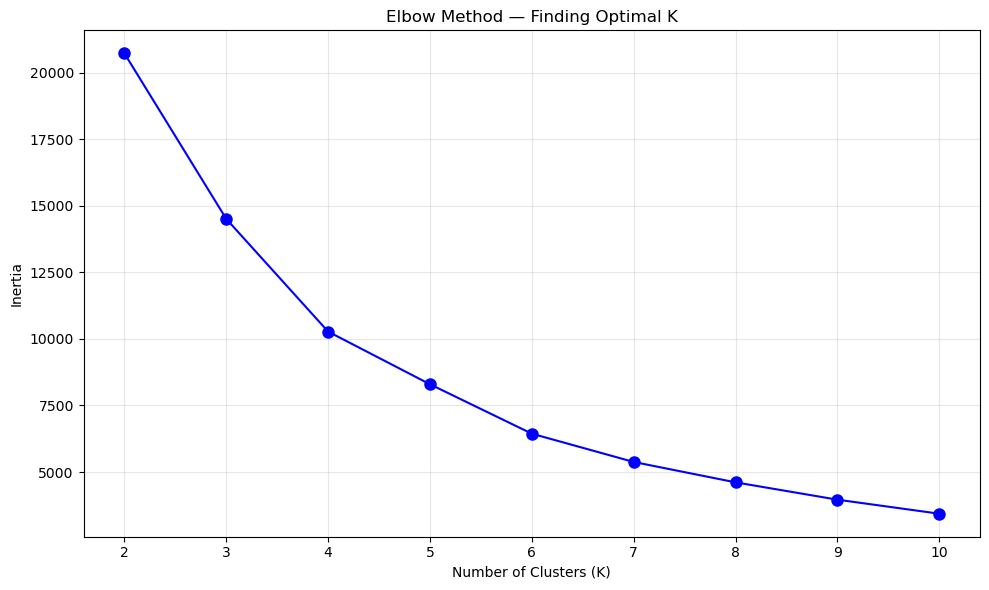

In [8]:
# ── Section 8: Elbow Method ──────────────────────────────────────
# We try KMeans with different K values (2 to 10)
# and plot the inertia for each
# Inertia = sum of distances from each point to its centroid
# Lower inertia = tighter clusters
# We look for the "elbow" — where adding more clusters
# stops giving significant improvement

inertias = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters =k, random_state = 42, n_init =10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10,6))
plt.plot(K_range, inertias,'bo-', markersize =8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')

## Section 9: Silhouette Score — Confirm Optimal K

K=2 → Silhouette Score: 0.3788
K=3 → Silhouette Score: 0.3797
K=4 → Silhouette Score: 0.4293
K=5 → Silhouette Score: 0.4344
K=6 → Silhouette Score: 0.4555
K=7 → Silhouette Score: 0.4386
K=8 → Silhouette Score: 0.4355
K=9 → Silhouette Score: 0.4443
K=10 → Silhouette Score: 0.4533


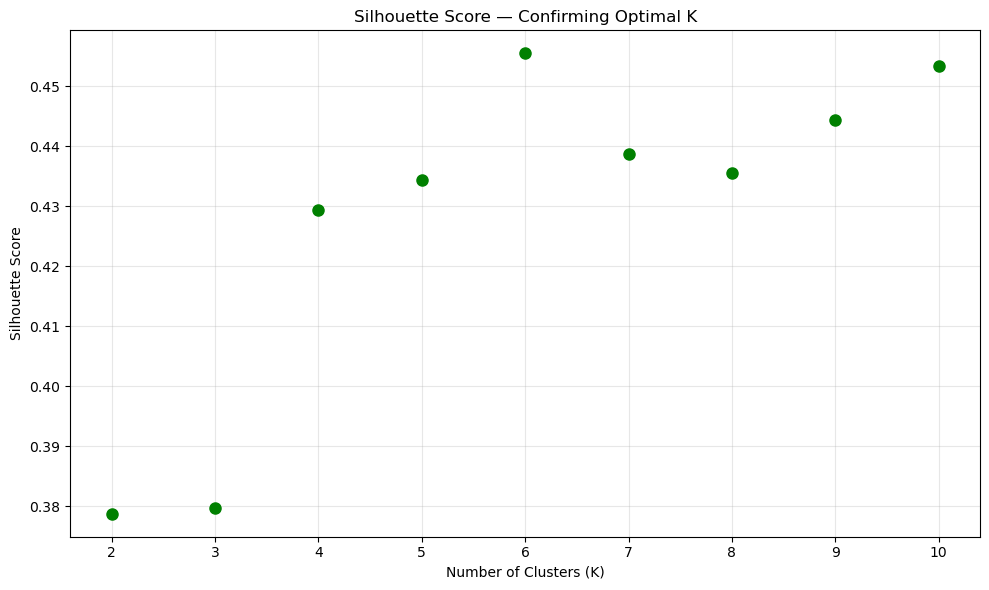

✅ Silhouette chart saved


In [9]:
# ── Section 9: Silhouette Score ──────────────────────────────────
# Silhouette score confirms what the elbow method showed
# It measures how well separated the clusters are
# Score between -1 and 1:
# → Close to 1  = clusters are well separated ✅
# → Close to 0  = clusters overlap
# → Close to -1 = points in wrong cluster ❌

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]

plt.figure(figsize=(10,6))
plt.plot(K_range, silhouette_scores, 'go', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Confirming Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha =0.3)
plt.tight_layout()
plt.savefig('screenshots/silhouette_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Silhouette chart saved")

## Section 10: KMeans Training with Optimal K=4

In [10]:
# ── Section 10: KMeans Training ──────────────────────────────────
# We now train KMeans with K=4
# confirmed by both elbow method and silhouette score

In [11]:
K_OPTIMAL = 4
kmeans_final = KMeans(n_clusters=K_OPTIMAL,
random_state=42,
n_init=10
)
# Train on scaled data and get cluster assignments
df_cluster['segments'] = kmeans_final.fit_predict(df_scaled)
print(f"✅ KMeans trained with K={K_OPTIMAL}")
print(f"\nSegment distribution:")
print(df_cluster['segments'].value_counts().sort_index())
print(f"\nTotal Customers : {len(df_cluster):.2f}")

✅ KMeans trained with K=4

Segment distribution:
segments
0    2219
1    2043
2    1696
3    1074
Name: count, dtype: int64

Total Customers : 7032.00


## Section 11: Segment Profiling and Naming

In [12]:
# ── Section 11: Segment Profiling and Naming ─────────────────────

# Check column name first
print("Columns in df_cluster:")
print(df_cluster.columns.tolist())
print()

# Add Churn and Contract back
df_cluster['Churn'] = df['Churn'].reset_index(drop=True)
df_cluster['Contract'] = df['Contract'].reset_index(drop=True)

# Profile each segment
profile = df_cluster.groupby('segments').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'ARPU': 'mean',
    'SeniorCitizen': 'mean'
}).round(2)

print("Segment Profiles:")
print(profile)
print()

# Churn rate per segment
churn_rate = df_cluster.groupby('segments')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)

print("Churn Rate per Segment (%):")
print(churn_rate)

# ── Segment Naming ────────────────────────────────────────────────
# Based on profile analysis — name each segment

segment_names = {
    0: 'Low Value Mid-Tenure',
    1: 'High Value At Risk',
    2: 'High Value Loyal',
    3: 'Senior High Value'
}
df_cluster['segment_name'] = df_cluster['segments'].map(segment_names)
print("✅ Segments named:")

for seg, name in segment_names.items():
    count = (df_cluster['segments']==seg).sum()
    churn = churn_rate[seg]
    arpu = profile.loc[seg, 'ARPU']
    print(f"\n  Segment {seg}: {name}")
    print(f"  → Customers: {count:,}")
    print(f"  → ARPU: {arpu}")
    print(f"  → Churn Rate: {churn}%")

Columns in df_cluster:
['tenure', 'MonthlyCharges', 'TotalCharges', 'ARPU', 'SeniorCitizen', 'segments']

Segment Profiles:
          tenure  MonthlyCharges  TotalCharges   ARPU  SeniorCitizen
segments                                                            
0          27.52           27.22        735.74  27.12           0.03
1          14.84           75.17       1116.18  75.28           0.00
2          59.07           89.72       5288.24  89.77           0.00
3          33.92           83.37       2955.62  83.27           1.00

Churn Rate per Segment (%):
segments
0    26.86
1    28.29
2    24.29
3    25.98
Name: Churn, dtype: float64
✅ Segments named:

  Segment 0: Low Value Mid-Tenure
  → Customers: 2,219
  → ARPU: 27.12
  → Churn Rate: 26.86%

  Segment 1: High Value At Risk
  → Customers: 2,043
  → ARPU: 75.28
  → Churn Rate: 28.29%

  Segment 2: High Value Loyal
  → Customers: 1,696
  → ARPU: 89.77
  → Churn Rate: 24.29%

  Segment 3: Senior High Value
  → Customers: 1,074
  

## Section 12: PCA Visualisation — Plot the Clusters

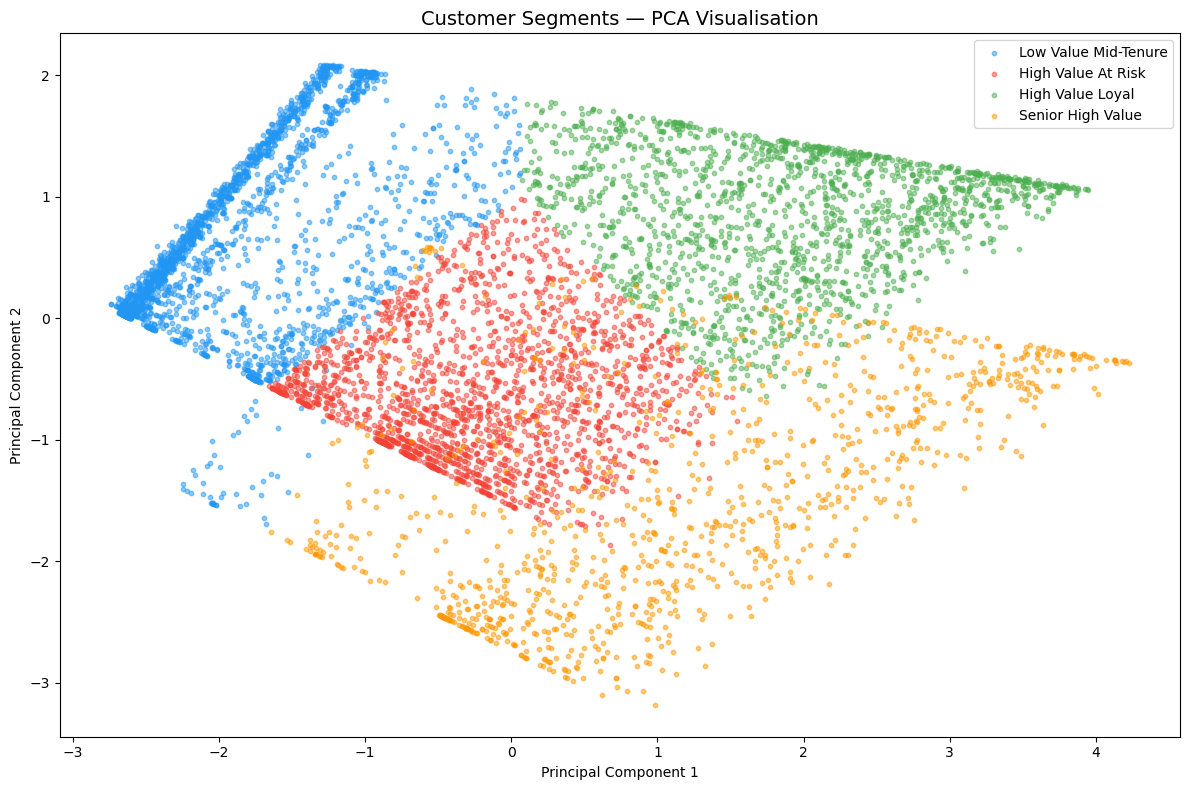

✅ PCA visualisation saved


In [13]:
# ── Section 12: PCA Visualisation ────────────────────────────────
# Variables from previous sections:
# df_pca → Section 7 — 2D representation of customers
# df_cluster → Section 11 — has 'segments' column
# segment_labels → Section 11 — segment names dictionary

colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
segment_labels = {
    0: 'Low Value Mid-Tenure',
    1: 'High Value At Risk',
    2: 'High Value Loyal',
    3: 'Senior High Value'
}

plt.figure(figsize=(12, 8))

for seg in range(4):
    mask = df_cluster['segments'] == seg
    plt.scatter(
        df_pca[mask, 0],
        df_pca[mask, 1],
        c=colors[seg],
        label=segment_labels[seg],
        alpha=0.5,
        s=10
    )

plt.title('Customer Segments — PCA Visualisation', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA visualisation saved")

## Section 13: MLflow Experiment Tracking

In [22]:
# ── Section 13: MLflow Tracking ──────────────────────────────────
# Variables from previous sections:
# K_OPTIMAL → Section 10 — value 4
# K_range → Section 8 — range(2,11)
# silhouette_scores → Section 9 — list of scores
# best_k → Section 9 — best K value
# pca → Section 7 — PCA object
# df_cluster → Section 11 — has segments column

mlflow.set_experiment("customer-segmentation")
with mlflow.start_run(run_name="kmeans-k4-final"):
    # Log parameters — what settings we used
    mlflow.log_param("k_optimal", K_OPTIMAL)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_param("pca_components", 2)
    mlflow.log_param("pca_variance_retained", round(sum(pca.explained_variance_ratio_),4))
    mlflow.log_param("n_clusters", len(df_cluster))
    mlflow.log_param("Random_state", 42)

    # Log metrics
    mlflow.log_metric("silhouette_score_k4", silhouette_scores[list(K_range).index(4)])
    mlflow.log_metric("best_silhouette_score", best_k)

    #log segment sizes
    for seg in range(4):
        count = (df_cluster['segments']==seg).sum()
        mlflow.log_metric(f"segment_{seg}_size", count)
    
    print("✅ MLflow experiment logged")
    print(f"   Experiment: customer-segmentation")
    print(f"   Run: kmeans-k4-final")
    print(f"   K optimal: {K_OPTIMAL}")
    print(f"   Silhouette at K=4: {silhouette_scores[list(K_range).index(4)]:.4f}")
    print(f"   Best silhouette: {max(silhouette_scores):.4f}")


✅ MLflow experiment logged
   Experiment: customer-segmentation
   Run: kmeans-k4-final
   K optimal: 4
   Silhouette at K=4: 0.4293
   Best silhouette: 0.4555


## Section 14: Results Summary Table

In [24]:
# ── Section 14: Results Summary Table ────────────────────────────
# Variables from previous sections:
# df_cluster → Section 11 — has segments, segment_name, Churn
# profile → Section 11 — average stats per segment
# churn_rate → Section 11 — churn % per segment
# segment_names → Section 11 — segment name dictionary

# Build a clean summary table
summary = pd.DataFrame({
    'segment' : list(segment_names.values()),
    'Customers' : [(df_cluster['segments']==i).sum() for i in range(4)],
    'Avg Monthly Charges': profile['MonthlyCharges'].values,
    'Avg Monthly Charges': profile['MonthlyCharges'].values,
    'Churn Rate (%)': churn_rate.values
})

# Add business action column
summary['Recommended Action'] = [
    'Upsell to higher plan',
    'Immediate retention call',
    'Loyalty rewards programme',
    'Senior-specific offers'
]

print("✅ Customer Segmentation Results")
print("=" * 70)
print(summary.to_string(index=False))
print()
print(f"Total customers analysed: {len(df_cluster):,}")
print(f"Optimal K: {K_OPTIMAL}")
print(f"Silhouette Score at K=4: {silhouette_scores[list(K_range).index(4)]:.4f}")

✅ Customer Segmentation Results
             segment  Customers  Avg Monthly Charges  Churn Rate (%)        Recommended Action
Low Value Mid-Tenure       2219                27.22           26.86     Upsell to higher plan
  High Value At Risk       2043                75.17           28.29  Immediate retention call
    High Value Loyal       1696                89.72           24.29 Loyalty rewards programme
   Senior High Value       1074                83.37           25.98    Senior-specific offers

Total customers analysed: 7,032
Optimal K: 4
Silhouette Score at K=4: 0.4293


## Section 15: Save Results and Push to GitHub

In [26]:
# ── Section 15: Save Results ──────────────────────────────────────
import os

# Create data folder if it does not exist
os.makedirs('data', exist_ok=True)

# Save the results table to CSV
summary.to_csv('data/segmentation_results.csv', index=False)
print("✅ Results saved to data/segmentation_results.csv")

# Save df_cluster with segment names
df_cluster.to_csv('data/customers_segmented.csv', index=False)
print("✅ Segmented customers saved to data/customers_segmented.csv")

print("\n📊 Final Summary:")
print(f"   Total customers: {len(df_cluster):,}")
print(f"   Segments: {K_OPTIMAL}")
print(f"   Silhouette Score: {silhouette_scores[list(K_range).index(4)]:.4f}")
print(f"   Charts saved: screenshots/")
print(f"   MLflow experiment: customer-segmentation")
print(f"\n✅ Week 3 ML notebook complete — ready for FastAPI")


✅ Results saved to data/segmentation_results.csv
✅ Segmented customers saved to data/customers_segmented.csv

📊 Final Summary:
   Total customers: 7,032
   Segments: 4
   Silhouette Score: 0.4293
   Charts saved: screenshots/
   MLflow experiment: customer-segmentation

✅ Week 3 ML notebook complete — ready for FastAPI
